# Apple Quality on Machine and Deep Learning Models

In [1]:
# Uncomment following lines in case packages are not installed.

# !pip install tensorflow
# !pip install tensorflow_hub

In [2]:
%%capture

# Imports common libraries.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import random, itertools, os, datetime
import kagglehub, shutil

from pathlib import Path
from importlib import reload

In [3]:
# Imports helper_functions module.
import extras.helper_functions as hf;
from importlib import reload;
reload(hf);

In [4]:
print(tf.__version__)

2.19.0


* The following lines download and move at separate directory dataset. In case dataset missing or never downloaded, uncommet the lines to proceed the execution.
* For speeding up the simulations, the following cell is commented out.

In [5]:
# # Downloads dataset file.
# import kagglehub, shutil
# from pathlib import Path

# current_path = str(Path.cwd())
# if not os.path.isdir('dataset'):
#     temp_path = kagglehub.dataset_download("nelgiriyewithana/apple-quality") # latest version
#     if os.name == "nt": # checks operating system ("nt" => windows)
#         shutil.copytree(temp_path, current_path + "\\dataset") # copies files into current directory
#         shutil.rmtree(temp_path.split("kagglehub")[0] + "kagglehub") # removes download files into "kagglehub": directory
#     else:
#         shutil.copytree(temp_path, current_path + "/dataset")

## 1. Loading and Visualizing of data

### 1.1 Loading Data

In [6]:
df = pd.read_csv("dataset/apple_quality.csv", delimiter = ',', skipfooter = 1)

In [7]:
df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,good
1,1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,good
2,2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,bad
3,3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,good
4,4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,good


In [8]:
df.tail()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
3995,3995,0.059386,-1.067408,-3.714549,0.473052,1.697986,2.244055,0.137784,bad
3996,3996,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235,good
3997,3997,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611,bad
3998,3998,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229720,good
3999,3999,0.278540,-1.715505,0.121217,-1.154075,1.266677,-0.776571,1.599796,good


### 1.2 Sub-dataFrame of min and max values from original dataframe.

In [9]:
# Creates a DataFrame containing min/max values of independent variables and possible values of dependent variable.
column_headers = list(df.columns.values)
df_values_stats = pd.DataFrame({v: [df[v].min(), df[v].max()] for k, v in enumerate(column_headers[:-1])}, index = ["min", "max"])
df_values_stats[column_headers[-1]] = sorted(df["Quality"].unique())
df_values_stats

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
min,0,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599,-7.010538,bad
max,3999,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837,7.404736,good


### 1.3 Visualizing data in graphs

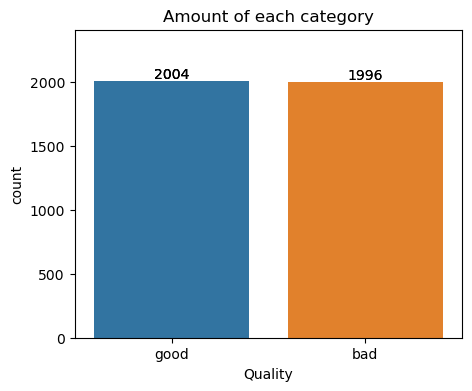

In [10]:
# Visualizing the amount of "Quality", which is separated in two categories.
plt.figure(figsize = (5, 4), dpi = 100)
ax = sns.countplot(data = df,
                   x = "Quality",
                   hue = "Quality")
y_max = 0
for container in ax.containers:
    ax.bar_label(container)
    if y_max < int(((ax.bar_label(container)[0]).get_text())):
        y_max = int(((ax.bar_label(container)[0]).get_text()))
plt.title("Amount of each category")
plt.ylim(0, round(y_max + (y_max * 0.2)));

## 2. Manipulation of data

### 2.1 Separates dataframe to independent (X) and dependent (y) arrays of values

In [11]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

### 2.2 Converting string variables to numeric from y array

In [12]:
# Fits and transform Quality via LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y[:] = le.fit_transform(y[:])
np.unique(y)

array([0, 1], dtype=object)

### 2.3 Splitting X and y to arrays for training and testing

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [14]:
X_train[:5]

array([[ 3.99400000e+03,  1.48250801e+00, -2.58118132e+00,
        -3.06887818e-01,  1.52787681e+00,  1.05636124e+00,
         2.56082901e+00, -1.22925459e+00],
       [ 4.23000000e+02, -1.66096708e-01,  3.85633008e-01,
        -1.10287541e+00,  4.73801502e-01,  3.25482818e-01,
         9.83244135e-01, -2.17193816e+00],
       [ 2.99100000e+03, -2.50889182e+00, -2.84343645e+00,
        -8.48363049e-01, -4.83351740e-01, -9.53368970e-02,
         5.11104610e+00, -1.80534781e+00],
       [ 1.22100000e+03, -1.38046294e+00, -5.21432155e-01,
         3.33571323e+00,  1.43991116e-01,  2.51375141e+00,
        -4.66678528e-01, -3.05330850e-02],
       [ 5.06000000e+02, -2.07363976e+00, -1.21283409e+00,
        -8.18440188e-01,  3.80883476e+00,  1.01386317e+00,
         7.48660841e-01,  2.61341950e-02]])

In [15]:
y_train[:5]

array([1, 1, 0, 0, 1], dtype=object)

In [16]:
pd.value_counts(pd.Series(y_train[:]))

1    1605
0    1595
Name: count, dtype: int64

#### 2.5 Converting arrays to float type from object

In [17]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

## 3. Modeling and Testing

### 3.1 Simulations with Machine Learning Algoritms (part 1)

#### 3.1.1 Define Machine Learning Classifiers

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

random_forest_cv_params = {
    "criterion": ["entropy"],
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10, 20]
}    

knn_cv_params = {
    "n_neighbors": [2, 3, 5, 10, 15, 20],
    "metric": ["minkowski", "manhattan"],
    "p": [1, 2]
}

# Defines classifiers and passes some basic parameters for each one.    
classifiers = {
    "Logistic Regression": LogisticRegression(),
    "K-Neighbours Classifier": hf.grid_search_cross_validation(estimator = KNeighborsClassifier(), param_grid = knn_cv_params, X_train = X_train, y_train = y_train),
    "Support Vector Classifier": SVC(C = 1, gamma = 0.1),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree Classifier": DecisionTreeClassifier(criterion = "entropy"),
    "Random Forest Classifier": hf.grid_search_cross_validation(estimator = RandomForestClassifier(), param_grid = random_forest_cv_params,X_train = X_train, y_train = y_train)
}

#### 3.1.2 Define metrics to measure the efficieny of each classifier

In [19]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Initializes an empty list to store results.
results = []
for name, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)

    # Calcualating the metrics to evaluate the succession of each classifier.
    res = hf.classfier_results(y_true = y_test, y_pred = y_pred)
    results.append({
        "classifier": name,
        "accuracy": res[0],
        "f1-Score": res[1],
        "precision": res[2],
        "recall": res[3],
        "y_pred": y_pred
    })

df_results = pd.DataFrame(results)

#### 3.1.3 Finding the best classifier based on the accuracy results

In [20]:
print(df_results)

                  classifier  accuracy  f1-Score  precision  recall  \
0        Logistic Regression    0.7538    0.7535     0.7547  0.7538   
1    K-Neighbours Classifier    0.5837    0.5834     0.5839  0.5838   
2  Support Vector Classifier    0.5713    0.5673     0.5742  0.5712   
3       Gaussian Naive Bayes    0.7650    0.7650     0.7652  0.7650   
4   Decision Tree Classifier    0.8237    0.8237     0.8238  0.8238   
5   Random Forest Classifier    0.9038    0.9037     0.9039  0.9038   

                                              y_pred  
0  [1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...  
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, ...  
2  [0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...  
3  [0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...  
4  [1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, ...  
5  [1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...  


In [21]:
best_classifier = ""
accuracy = -1.0
for index, row in df_results.iterrows():
    if accuracy < row["accuracy"]:
        accuracy = row["accuracy"]
        best_classifier = index

print(f"Best classifier is '{df_results["classifier"][best_classifier]}' with acccuracy of {round(df_results["accuracy"][best_classifier] * 100, 2)}% .")

Best classifier is 'Random Forest Classifier' with acccuracy of 90.38% .


#### 3.1.4 Confusion Matrix

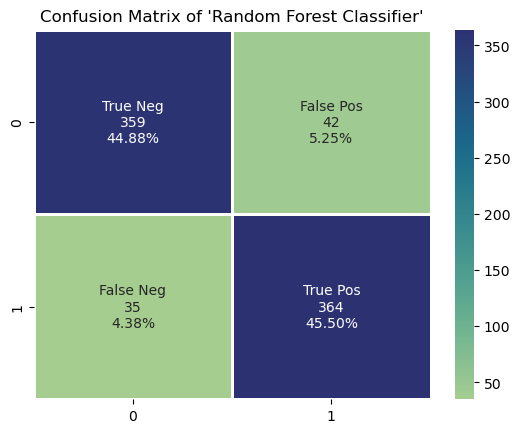

In [22]:
hf.custom_confusion_matrix(y_test, df_results['y_pred'][best_classifier], title = f"Confusion Matrix of '{df_results["classifier"][best_classifier]}'")

* Simulating with a group of machine learning algorithms above, deduce 'Random Forest Classifier' has the best generalization on this problem.
* Getting approximately 90% succession, it is very reasonable and reliable percentage, which under some circumstances could be increased a little bit more (adding more parameters on classifier etc.)
* Additionaly, this specific dataset (as is shown) it is a balanced dataset because it has equivalent amount of observation in both categories (good, bad)
* In the next step, it will be tried a simulation with the best classifiet, but with normalized values on independent variables.

### 3.2 Normilazation of data

#### 3.2.1 Getting normalized data

In [23]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [24]:
best_estimator = list(classifiers.values())[index]
best_estimator

RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_split=5,
                       n_estimators=200)

In [25]:
best_estimator.fit(X_train, y_train)
y_pred = best_estimator.predict(X_test)

In [26]:
print(hf.classfier_results(y_true = y_test, y_pred = y_pred))

[0.905, 0.905, 0.9052, 0.905]


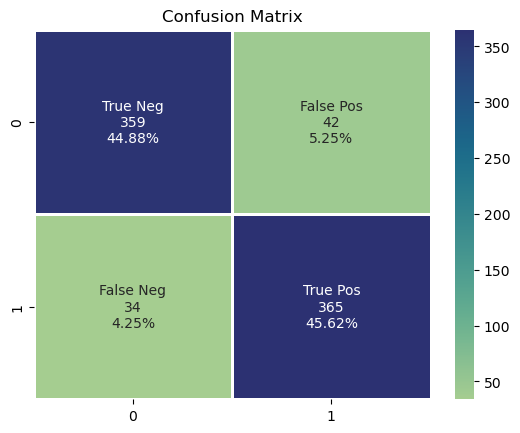

In [27]:
hf.custom_confusion_matrix(y_test, y_pred, title = f"Confusion Matrix")

### 3.3 Simulations on Deep Learning (part 2)

#### -> Model 1

In [28]:
# Creates ann model.
tf.random.set_seed(42)
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(units = 1)
])

In [29]:
# Compiles model.
model_1.compile(loss = "binary_crossentropy",
                optimizer = tf.keras.optimizers.SGD(learning_rate = 0.01),
                metrics = ["accuracy"])

In [30]:
# Creates callback for EarlyStopping if model does not improved after certain epochs.
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = "loss",
                                                  patience = 2)

In [31]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
history_1 = model_1.fit(x = X_train,
                        y = y_train,
                        epochs = 50,
                        callbacks = [early_stopping])

AttributeError: module 'ml_dtypes' has no attribute 'float4_e2m1fn'
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4851 - loss: 6.2591
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6207 - loss: 3.6668
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - accuracy: 0.7088 - loss: 2.6327
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7297 - loss: 1.5126  
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7360 - loss: 0.7537  
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7335 - loss: 0.6222  
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7362 - loss: 0.5707
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7394 - loss: 0.5695  
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7392 - loss: 0.5859  
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7363 - loss: 0.5708  


In [33]:
y_pred = model_1.predict(X_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step


In [34]:
# Converts results to actual targets options ( 0 or 1 ).
y_pred = np.where(y_pred > 0.5, 1, 0)
y_pred = np.squeeze(y_pred)

In [35]:
# Accuracy of predictions on test data.
print(f"The model's prediction accuracy is: {round(accuracy_score(y_test, y_pred), 2) * 100}%.")

The model's prediction accuracy is: 75.0%.


#### -> Model 2

In [36]:
tf.random.set_seed(42)
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(units = 1)
])

model_2.compile(loss = "binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

history_2 = model_2.fit(x = X_train,
                        y = y_train,
                        epochs = 50,
                        callbacks = [early_stopping])

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5509 - loss: 5.2918
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - accuracy: 0.5557 - loss: 5.1893
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - accuracy: 0.5633 - loss: 5.0684
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5736 - loss: 4.9035  
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5744 - loss: 4.9123  
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5758 - loss: 4.9101
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5768 - loss: 4.9084  
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5769 - loss: 4.9067
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5772 - loss: 4.9015  
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5771 - loss: 4.8864  
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5762 - loss: 4.8712  
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━

In [37]:
y_pred = model_2.predict(X_test)

y_pred = np.where(y_pred > 0.5, 1, 0)
y_pred = np.squeeze(y_pred)

print(f"The model's prediction accuracy is: {round(accuracy_score(y_test, y_pred), 2) * 100}%.")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step
The model's prediction accuracy is: 64.0%.


#### -> Model 3 

In [38]:
def scheduler(epoch, lr):
    if epoch < 5:
        return lr
    else:
        return lr * 1/(1 + 0.1 * 1)

learning_rate_callback_5 = tf.keras.callbacks.LearningRateScheduler(scheduler)

In [39]:
tf.random.set_seed(42)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(units = 5),
    tf.keras.layers.Dense(units = 1)
])

model_3.compile(loss = "binary_crossentropy",
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["accuracy"])

history_3 = model_2.fit(x = X_train,
                        y = y_train,
                        epochs = 50,
                        callbacks = [early_stopping, learning_rate_callback_5])

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6535 - loss: 3.5885 - learning_rate: 0.0010
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6533 - loss: 3.5315 - learning_rate: 0.0010
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6571 - loss: 3.5017 - learning_rate: 0.0010
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6608 - loss: 3.4667 - learning_rate: 0.0010
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - accuracy: 0.6675 - loss: 3.4209 - learning_rate: 0.0010
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6703 - loss: 3.3348 - learning_rate: 9.0909e-04
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6718 - loss: 3.3228 - learning_rate: 8.2645e-04
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6728 - loss: 3.2766 - learning_rate: 7.5131e-04
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6767 - loss: 3.2415 - learning_rate: 6.8

In [40]:
y_pred = model_3.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
y_pred = np.squeeze(y_pred)
print(f"The model's prediction accuracy is: {round(accuracy_score(y_test, y_pred), 2) * 100}%.")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
The model's prediction accuracy is: 57.99999999999999%.


#### -> Model 4

In [41]:
tf.random.set_seed(42)
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(units = 10),
    tf.keras.layers.Dense(units = 1)
])

model_4.compile(loss = "binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

history_4 = model_4.fit(x = X_train,
                        y = y_train,
                        epochs = 50,
                        callbacks = [early_stopping])

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4168 - loss: 7.0326
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4327 - loss: 6.5359
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4457 - loss: 6.2873
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4543 - loss: 5.9789
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4967 - loss: 5.0010
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5208 - loss: 4.4697
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5345 - loss: 3.6572
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5907 - loss: 2.4059
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6356 - loss: 1.6681
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6851 - loss: 1.2042
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7084 - loss: 0.9363
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

In [42]:
y_pred = model_4.predict(X_test)

y_pred = np.where(y_pred > 0.5, 1, 0)
y_pred = np.squeeze(y_pred)

print(f"The model's prediction accuracy is: {round(accuracy_score(y_test, y_pred), 2) * 100}%.")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
The model's prediction accuracy is: 67.0%.


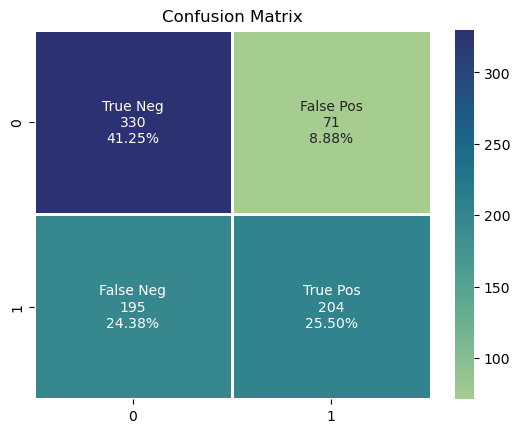

In [43]:
# Confusion Matrix
hf.custom_confusion_matrix(y_true = y_test, y_pred = y_pred)

* As it is obvious, deep learning need datasets more compilacted an more observations on thems.
* We succeed around 75% accuracy, but we could not increase it more, because we will face an overfitting issues.
* So, the best solution is to use machine learning algoriths for simulations, and if it is necessary to get better accuracy percentages, it is possible to accomplish that with further investigation on parameters of classifiers.